# Phase 7: Churn Prediction

### Objective

Build a machine learning model to identify customers who are likely to churn using engineered customer features and RFM analysis.

### Dataset

- `rfm_customer_segments.csv`

### Workflow

1. Load Dataset
2. Define Churn
3. Exploratory Churn Analysis
4. Prepare Features
5. Train-Test Split
6. Train Machine Learning Models
7. Evaluate Models
8. Feature Importance
9. Predict High-Risk Customers
10. Business Insights

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

%matplotlib inline

In [2]:
# Load RFM customer dataset

rfm = pd.read_csv(
    "../data/processed/rfm_customer_segments.csv"
)

# Display first five rows

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,4,414,Potential Loyalists
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1,411,Potential Loyalists
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,112,Lost Customers
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,211,Lost Customers
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4,214,Lost Customers


### Define Churn

In [3]:
# Create churn label

rfm["Churn"] = np.where(
    (rfm["Recency"] > 180) &
    (rfm["Frequency"] <= 2),
    1,
    0
)

# Display first five rows

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Customer_Segment,Churn
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,4,414,Potential Loyalists,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1,411,Potential Loyalists,0
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,112,Lost Customers,1
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,211,Lost Customers,1
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4,214,Lost Customers,1


In [4]:
# Count churned and non-churned customers

rfm["Churn"].value_counts()

Churn
1    67963
0    28133
Name: count, dtype: int64

In [5]:
# Calculate churn percentage

(
    rfm["Churn"]
    .value_counts(normalize=True)
    * 100
).round(2)

Churn
1    70.72
0    29.28
Name: proportion, dtype: float64

In [6]:
# Count churned and non-churned customers

churn_counts = (
    rfm["Churn"]
    .value_counts()
    .reset_index()
)

# Rename columns

churn_counts.columns = [
    "Churn",
    "Customer_Count"
]

# Display results

churn_counts

,Churn,Customer_Count
0,1,67963
1,0,28133


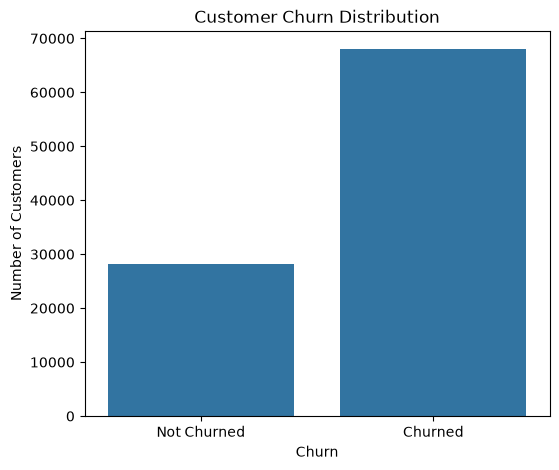

In [7]:
# Create churn distribution chart

plt.figure(figsize=(6,5))

sns.countplot(
    data=rfm,
    x="Churn"
)

# Add title and labels

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Rename x-axis labels

plt.xticks(
    [0,1],
    ["Not Churned","Churned"]
)

plt.show()

In [ ]:
### Prepare Machine Learning Dataset

In [8]:
# Select input features

X = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
]

# Select target variable

y = rfm["Churn"]

# Display first five rows

X.head()

,Recency,Frequency,Monetary
0,160,1,141.90
1,163,1,27.19
2,585,1,86.22
3,369,1,43.62
4,336,1,196.89


In [10]:
# Display feature shape

X.shape


(96096, 3)

In [11]:
# Display target shape

y.shape

(96096,)

In [12]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display dataset shapes

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (76876, 3)
Testing Features  : (19220, 3)
Training Labels   : (76876,)
Testing Labels    : (19220,)
